# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [35]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [36]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

### $\beta$ Estimation

In [26]:
φ = 0.5
λ = -0.5
γ = 0.5
β = 0.5
npts = 1000

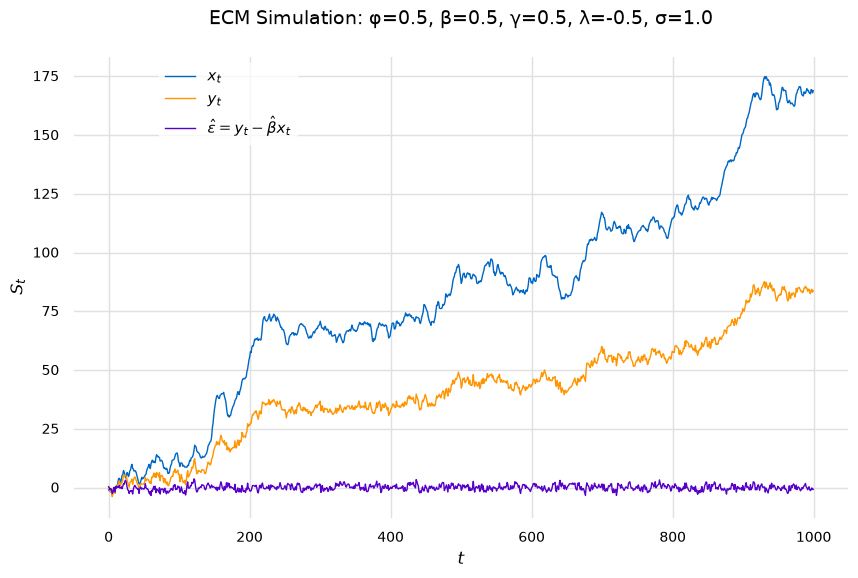

In [37]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [38]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │  -7.24908     │
├────────────────┼───────────────┤
│ pvalue         │   1.66851e-11 │
├────────────────┼───────────────┤
│ Lags           │  10           │
├────────────────┼───────────────┤
│ Number Obs     │ 989           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.568   │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61655 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [29]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "943d5cb6-6aad-4a38-bd9e-e169d66bfe0d",
                "label": "$t$",
                "value": -18.763197085063112
            },
            "pval": {
                "test_id": "943d5cb6-6aad-4a38-bd9e-e169d66bfe0d",
                "label": "$p-value$",
                "value": 3.5713678568588584e-29
            },
            "params": [],
            "sig": {
                "test_id": "943d5cb6-6aad-4a38-bd9e-e169d66bfe0d",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "943d5cb6-6aad-4a38-bd9e-e169d66bfe0d",
                "label": "$t_L$",
                "value": -2.5679816723029334
            },
            "upper": null,
            "test_id": "943d5cb6-6aad-4a38-bd9e-e169d66bfe0d"
        },
 

In [30]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 6.967e+04
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:42:46   Log-Likelihood:                -1575.4
No. Observations:                1000   AIC:                             3155.
Df Residuals:                     998   BIC:                             3165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0432      0.073      0.595      0.552      -0.099       0.186
x1             0.5006      0.002    263.950      0.000       0.497       0.504
==============================================================================
Omnibus:                        0.153   Durbin-Watson:                   1.044
Prob(Omnibus):                  0.927   Jarque-Bera (JB):                0.101
Skew:                           0.021   Prob(JB):                        0.951
Kurtosis:                       3.025   Cond. No.                         75.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.04323696500271845,
      "err": 0.07267325692504881,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "5dd7db32-1585-4a76-b2ff-fd54871908b8",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.500618682701427,
         "err": 0.0018966385522531826,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "5dd7db32-1585-4a76-b2ff-fd54871908b8",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9858775976228508,
   "param_transforms": [
      {
         "param": {
            "est": 0.500618682701427,
            "err": 0.0018966385522531826,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            "ord

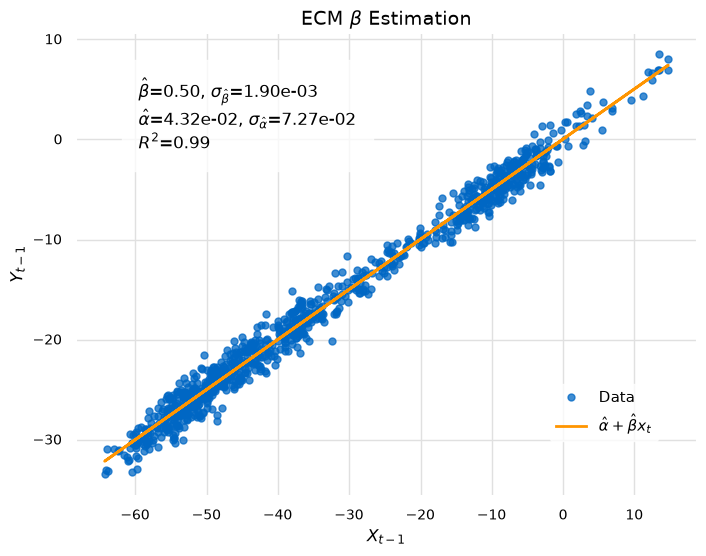

In [32]:
ecm_beta(yt, beta_result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [33]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     330.5
Date:                Sun, 23 Aug 2026   Prob (F-statistic):          8.35e-111
Time:                        15:42:46   Log-Likelihood:                -1444.8
No. Observations:                 999   AIC:                             2896.
Df Residuals:                     996   BIC:                             2910.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0240      0.033      0.734      0.463      -0.040       0.088
x1             0.5138      0.030     17.368      0.000       0.456       0.572
x2            -0.5219      0.028    -18.746      0.000      -0.577      -0.467
==============================================================================
Omnibus:                        1.708   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.426   Jarque-Bera (JB):                1.676
Skew:                           0.045   Prob(JB):                        0.432
Kurtosis:                       2.821   Cond. No.                         1.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.023965100288096276,
      "err": 0.03263456852503544,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "7044ee9e-133c-4aef-b9a9-0bda32292bfb",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5138492361035872,
         "err": 0.029586616588051878,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "7044ee9e-133c-4aef-b9a9-0bda32292bfb",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.5219460884219904,
         "err": 0.027843387298568525,
         "est_label": "$\\alpha_2$",
         "err_label": "$\\sigma_{\\alpha_2}$",
         "row": 0,
         "column": 2,
         "order": 0,
         "est_id": "7044ee9e-133c-4aef-b9a9-0bda32292bfb",
         "param_type": "OLS_PARAM"
    